In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [29]:
path = "/Users/jeongj/GitHub/EPGabors/results_resnet50_mean_orientation/classification/"

df = pd.read_csv(path+"resnet50_layer4_last_kfold_combined_predictions.csv")

lv_mean = np.unique(df['mean'])
lv_sd = np.unique(df['sd'])
lv_ss = np.unique(df['ss'])

print("lv_mean: ",lv_mean)
print("lv_sd: ",lv_sd)
print("lv_ss: ",lv_ss)

lv_mean:  [-12  -8  -4   0   4   8  12]
lv_sd:  [ 0  4  8 16]
lv_ss:  [ 4  8 16 32]


In [7]:
df.columns

Index(['fold_id', 'layer_name', 'split', 'file_name', 'condition_id', 'mean',
       'sd', 'ss', 'instance', 'target', 'pred_class', 'decision_value',
       'correct', 'choice_cw', 'decoder_name'],
      dtype='object')

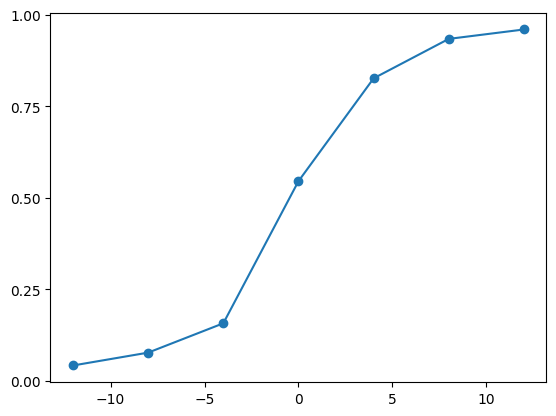

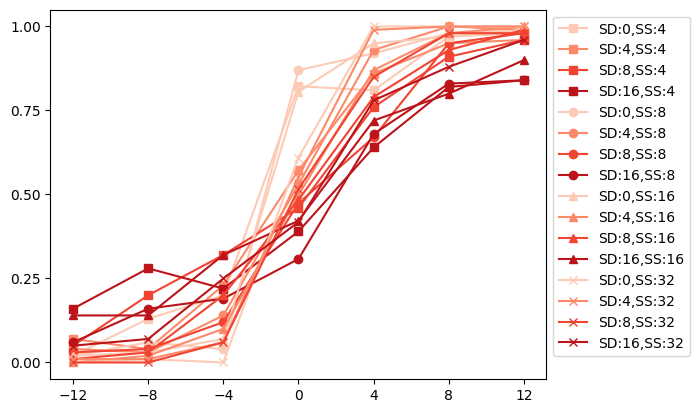

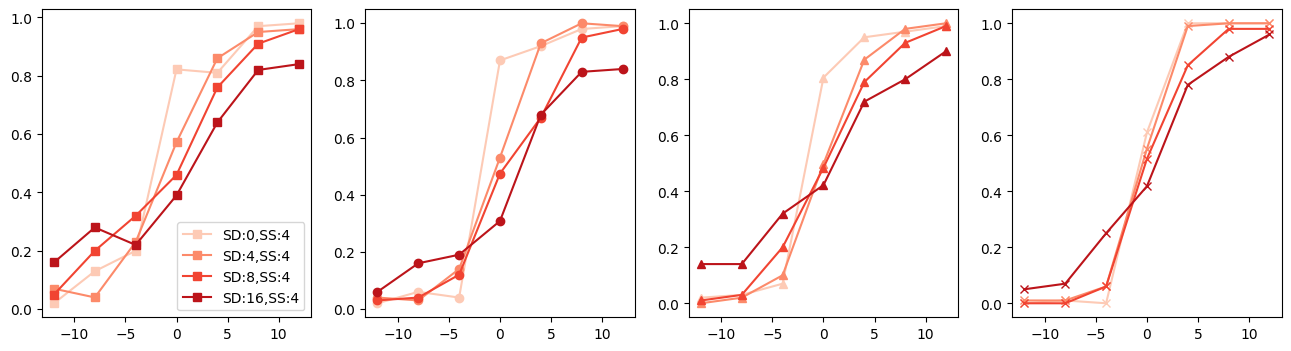

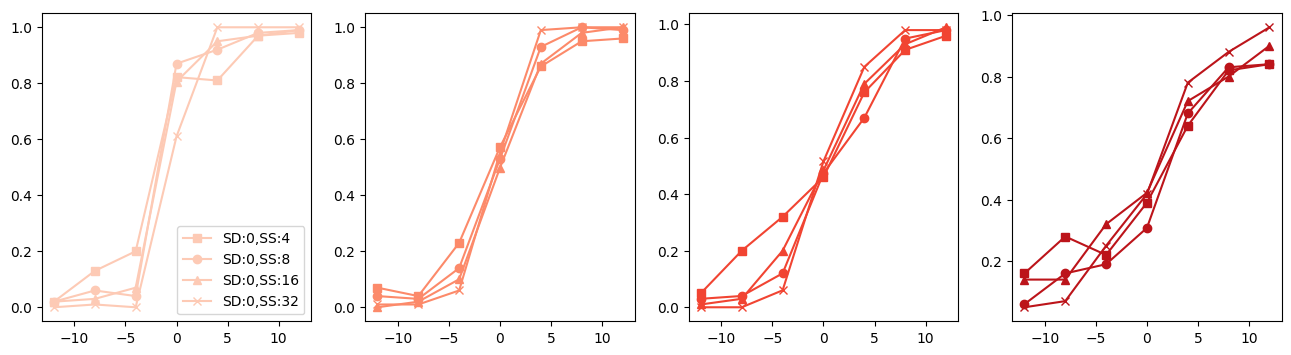

In [ ]:
tmp = df.groupby(['mean','fold_id']).agg({'pred_class':'mean'}).reset_index().groupby(['mean']).agg({'pred_class':'mean'}).reset_index()
plt.plot(tmp['mean'],tmp['pred_class'],'o-')
plt.yticks(np.arange(0,1.1,0.25));
plt.show() 

tmp = df.groupby(['mean','sd','ss']).agg({'pred_class':'mean'}).reset_index()
for i_ss, ss in enumerate(lv_ss):
    for i_sd, sd in enumerate(lv_sd):
        tmptmp = tmp[(tmp['ss']==ss)&(tmp['sd']==sd)].reset_index()
        plt.plot(tmptmp['mean'],tmptmp['pred_class'],'-',color=plt.cm.Reds(np.linspace(0.2,.8,4)[i_sd]),marker=['s','o','^','x'][i_ss],label=f"SD:{sd},SS:{ss}")

plt.yticks(np.arange(0,1.1,0.25))
plt.xticks(lv_mean)
plt.legend(bbox_to_anchor=(1,1));

# variance effect:
fig,axs=plt.subplots(1,4,figsize=(16,4))
# set size effect
fig2,axs2=plt.subplots(1,4,figsize=(16,4))
for i_ss, ss in enumerate(lv_ss):
    for i_sd, sd in enumerate(lv_sd):
        tmptmp = tmp[(tmp['ss']==ss)&(tmp['sd']==sd)].reset_index()
        axs[i_ss].plot(tmptmp['mean'],tmptmp['pred_class'],'-',color=plt.cm.Reds(np.linspace(0.2,.8,4)[i_sd]),marker=['s','o','^','x'][i_ss],label=f"SD:{sd},SS:{ss}")
        axs2[i_sd].plot(tmptmp['mean'],tmptmp['pred_class'],'-',color=plt.cm.Reds(np.linspace(0.2,.8,4)[i_sd]),marker=['s','o','^','x'][i_ss],label=f"SD:{sd},SS:{ss}")

axs[0].legend()
axs2[0].legend()
for i in range(4):
    axs[i].set_yticks(np.arange(0,1.1,0.25))
    axs2[i].set_yticks(np.arange(0,1.1,0.25))

    axs[i].set_xticks(lv_mean)
    axs2[i].set_xticks(lv_mean)